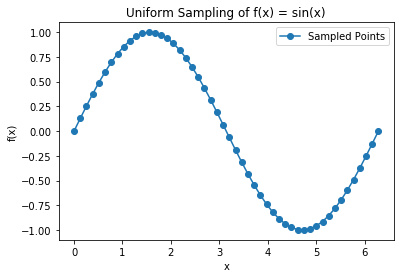

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function and the domain
f = lambda x: np.sin(x)
a, b = 0, 2 * np.pi  # Interval
N = 50  # Number of sample points

# Create a uniform grid
x = np.linspace(a, b, N)
y = f(x)

# Plot the sampled points
plt.plot(x, y, 'o-', label='Sampled Points')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Uniform Sampling of f(x) = sin(x)')
plt.legend()
plt.show()

In [9]:
# Step size
h = (b - a) / (N - 1)
print(h)
print(x)

0.1282282715750936
[0.         0.12822827 0.25645654 0.38468481 0.51291309 0.64114136
 0.76936963 0.8975979  1.02582617 1.15405444 1.28228272 1.41051099
 1.53873926 1.66696753 1.7951958  1.92342407 2.05165235 2.17988062
 2.30810889 2.43633716 2.56456543 2.6927937  2.82102197 2.94925025
 3.07747852 3.20570679 3.33393506 3.46216333 3.5903916  3.71861988
 3.84684815 3.97507642 4.10330469 4.23153296 4.35976123 4.48798951
 4.61621778 4.74444605 4.87267432 5.00090259 5.12913086 5.25735913
 5.38558741 5.51381568 5.64204395 5.77027222 5.89850049 6.02672876
 6.15495704 6.28318531]


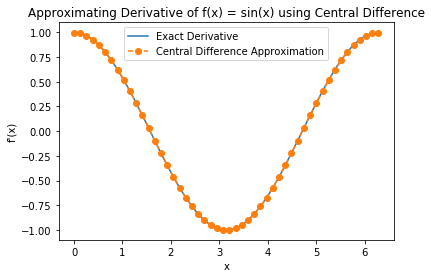

In [5]:
# Central Difference Approximation for the derivative
cent_df_dx = (f(x + h) - f(x - h)) / (2 * h)

# Plot the approximation and the true derivative
plt.plot(x, np.cos(x), label='Exact Derivative')
plt.plot(x, cent_df_dx, 'o--', label='Central Difference Approximation')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.title("Approximating Derivative of f(x) = sin(x) using Central Difference")
plt.legend()
plt.show()

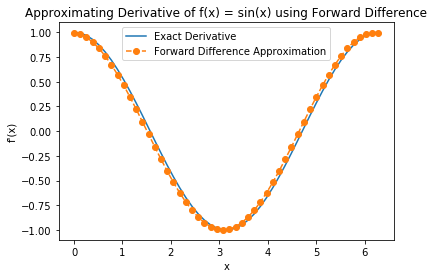

In [6]:
# Forward Difference Approximation for the derivative
for_df_dx = (f(x + h) - f(x)) / (h)

# Plot the approximation and the true derivative
plt.plot(x, np.cos(x), label='Exact Derivative')
plt.plot(x, for_df_dx, 'o--', label='Forward Difference Approximation')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.title("Approximating Derivative of f(x) = sin(x) using Forward Difference")
plt.legend()
plt.show()

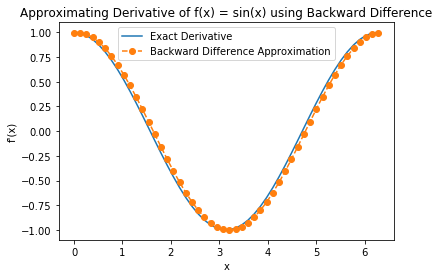

In [7]:
# Backward Difference Approximation for the derivative
back_df_dx = (f(x) - f(x - h)) / (h)

# Plot the approximation and the true derivative
plt.plot(x, np.cos(x), label='Exact Derivative')
plt.plot(x, back_df_dx, 'o--', label='Backward Difference Approximation')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.title("Approximating Derivative of f(x) = sin(x) using Backward Difference")
plt.legend()
plt.show()

/opt/conda/lib/python3.8/site-packages/scipy/sparse/linalg/dsolve/linsolve.py:132: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  warn('spsolve requires A be CSC or CSR matrix format',


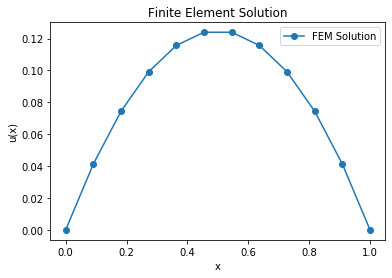

In [10]:
# finite element method

from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
# Problem setup
L = 1 # Length of the domain
N = 10 # Number of elements
h = L / (N + 1) # Element size

# Source term
f = np.ones(N)

# Assemble the system matrix
diagonals = [[-2] * N, [1] * (N - 1), [1] * (N - 1)]
A = diags(diagonals, [0, -1, 1]) / h**2

# Solve for u in Au = -f
u = spsolve(A, -f)

# Add boundary values (Dirichlet condition u(0) = u(1) = 0)
u = np.concatenate(([0], u, [0]))

# Plot the solution
x = np.linspace(0, L, N + 2)
plt.plot(x, u, 'o-', label='FEM Solution')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Finite Element Solution')
plt.legend()
plt.show()

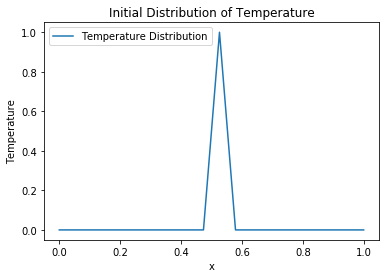

In [31]:
# Parameters
alpha = 0.01 # Diffusion coefficient
dx = 0.05
dt = 0.01
L = 1.0
Nx = int(L / dx)
u = np.zeros(Nx) # Initial temperature distribution
u[int(Nx/2)] = 1.0 # Initial heat at the center      [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
x = np.linspace(0, L, Nx)
plt.plot(x, u, label='Temperature Distribution')
plt.xlabel('x')
plt.ylabel('Temperature')
plt.title('Initial Distribution of Temperature')
plt.legend()

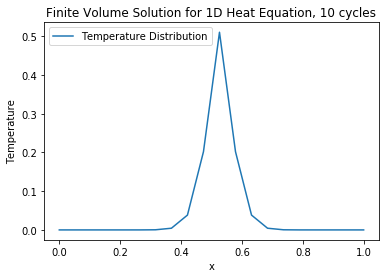

In [32]:
# finite volume method


# FVM discretization loop
for n in range(10):
    u_new = u.copy()
    for i in range(1, Nx - 1):
        u_new[i] = u[i] + alpha * dt / dx**2 * (u[i + 1] - 2 * u[i] + u[i - 1])
    u = u_new
    
# Plot the final temperature distribution
x = np.linspace(0, L, Nx)
plt.plot(x, u, label='Temperature Distribution')
plt.xlabel('x')
plt.ylabel('Temperature')
plt.title('Finite Volume Solution for 1D Heat Equation, 10 cycles')
plt.legend()
plt.show()

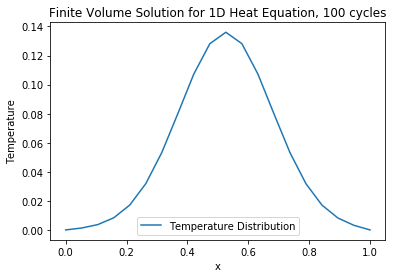

In [33]:
# FVM discretization loop
for n in range(100):
    u_new = u.copy()
    for i in range(1, Nx - 1):
        u_new[i] = u[i] + alpha * dt / dx**2 * (u[i + 1] - 2 * u[i] + u[i - 1])
    u = u_new
    
# Plot the final temperature distribution
x = np.linspace(0, L, Nx)
plt.plot(x, u, label='Temperature Distribution')
plt.xlabel('x')
plt.ylabel('Temperature')
plt.title('Finite Volume Solution for 1D Heat Equation, 100 cycles')
plt.legend()
plt.show()

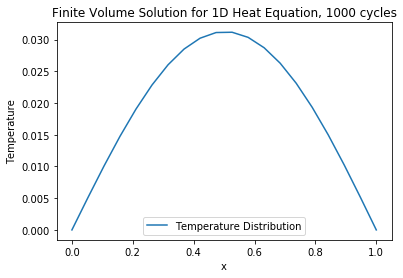

In [34]:
# FVM discretization loop
for n in range(1000):
    u_new = u.copy()
    for i in range(1, Nx - 1):
        u_new[i] = u[i] + alpha * dt / dx**2 * (u[i + 1] - 2 * u[i] + u[i - 1])
    u = u_new
    
# Plot the final temperature distribution
x = np.linspace(0, L, Nx)
plt.plot(x, u, label='Temperature Distribution')
plt.xlabel('x')
plt.ylabel('Temperature')
plt.title('Finite Volume Solution for 1D Heat Equation, 1000 cycles')
plt.legend()
plt.show()

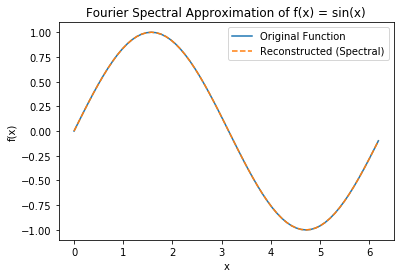

In [36]:
from scipy.fftpack import fft, ifft
# Sample the function on a periodic domain
N = 64
x = np.linspace(0, 2 * np.pi, N, endpoint=False)
f = np.sin(x)
# Compute Fourier transform and reconstruct
f_hat = fft(f)
f_reconstructed = ifft(f_hat).real
#  Plot the original and reconstructed function
plt.plot(x, f, label='Original Function')
plt.plot(x, f_reconstructed, '--', label='Reconstructed (Spectral)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Fourier Spectral Approximation of f(x) = sin(x)')
plt.legend()
plt.show()

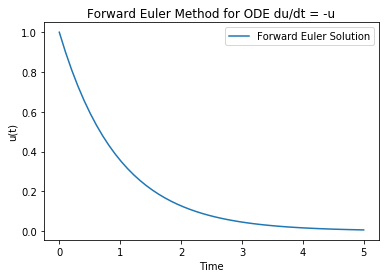

In [37]:
# forward euler method

# Define parameters
T = 5.0 # Final time
dt = 0.1 # Time step
N = int(T / dt)
u = np.zeros(N)
u[0] = 1 # Initial condition

# Time-stepping loop
for n in range(1, N):
    u[n] = u[n-1] - dt * u[n-1]
    
# Plot the solution
t = np.linspace(0, T, N)
plt.plot(t, u, label='Forward Euler Solution')
plt.xlabel('Time')
plt.ylabel('u(t)')
plt.title('Forward Euler Method for ODE du/dt = -u')
plt.legend()
plt.show()

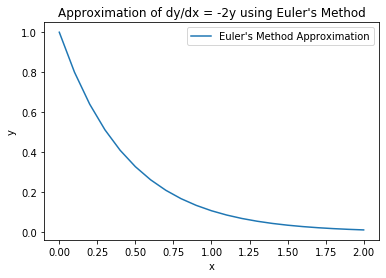

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
h = 0.1  # step size
x_start, x_end = 0, 2
num_steps = int((x_end - x_start) / h)
x_values = np.linspace(x_start, x_end, num_steps + 1)
y_values = np.zeros(num_steps + 1)

# Initial condition
y_values[0] = 1  # y(0) = 1

# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y

# Implement Euler's method
for i in range(num_steps):
    y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

# Plot the results
plt.plot(x_values, y_values, label="Euler's Method Approximation")
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.legend()
plt.show()